In [1]:
%pip install python-dotenv langchain-google-genai langgraph


Note: you may need to restart the kernel to use updated packages.


c:\Users\puroh\Desktop\langgraph-tutoril\.venv\Scripts\python.exe: No module named pip


In [2]:
from dotenv import load_dotenv
import os

load_dotenv()

if os.getenv("GOOGLE_API_KEY"):
    print("Google API key is set.")
else:
    raise ValueError("Google API key is not set.")


Google API key is set.


In [3]:

from langchain_google_genai import ChatGoogleGenerativeAI
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash"
)
model

ChatGoogleGenerativeAI(profile={'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), model='gemini-2.5-flash', client=<google.genai.client.Client object at 0x000002389B6A6BA0>, default_metadata=(), model_kwargs={})

In [4]:
model.invoke("what is the goof time for sex")

AIMessage(content='The "goof time" for sex is really whenever it feels right for *everyone involved*! There\'s no single perfect time, as it varies greatly depending on:\n\n1.  **Your Energy Levels:** Some people feel most frisky in the morning after a good night\'s sleep, while others prefer the evening when they\'re winding down.\n2.  **Your Mood:** When you\'re feeling connected, relaxed, playful, or simply in the mood for intimacy.\n3.  **Privacy and Opportunity:** When you have the time and space to be intimate without interruptions or worries.\n4.  **Your Partner\'s Availability and Desire:** This is the most crucial one! The "goof time" is always when both (or all) partners are enthusiastic and consenting.\n5.  **Spontaneity vs. Planning:** Sometimes the best times are completely unplanned and impulsive. Other times, planning a special date or evening can build anticipation and make it feel extra special.\n\n**Common "goof times" people often mention:**\n\n*   **Mornings:** When

In [6]:
from pydantic import BaseModel, Field 

class graph_schema(BaseModel):

    topic: str = Field(description="The topic of the graph")
    post: str = Field(description="The LinkedIn post content")
    curated_post: str = Field(description="The curated LinkedIn post content")


demo_obj = graph_schema(
    topic="The importance of data privacy in the digital age",
    post="Data privacy is crucial in today's digital world. With the increasing amount of personal information being shared online, it's important to understand how to protect your data and maintain your privacy.",
    curated_post="In the digital age, data privacy is more important than ever. With the"
)
print(demo_obj)


topic='The importance of data privacy in the digital age' post="Data privacy is crucial in today's digital world. With the increasing amount of personal information being shared online, it's important to understand how to protect your data and maintain your privacy." curated_post='In the digital age, data privacy is more important than ever. With the'


In [9]:
def create_post(state: graph_schema) -> graph_schema:
    
    # Convert the Pydantic model to a dictionary
    state = state.model_dump()

    # Extract the topic from the state
    topic = state['topic']

    # Passing the topic to the LLM to generate a LinkedIn post
    post = model.invoke(f"Write a LinkedIn post about {topic}").content

    # Update the state with the generated post
    state['post'] = post

    return state


def curate_post(state: graph_schema) -> graph_schema:

    # Convert the Pydantic model to a dictionary
    state = state.model_dump()

    # Extract the post from the state
    post = state['post']

    # Passing the post to the LLM to curate it
    curated_post = model.invoke(f"Curate the following LinkedIn post with GenZ tone: {post}").content


    # Update the state with the curated post
    state['curated_post'] = curated_post

    return state

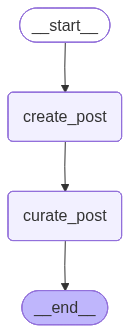

In [10]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("create_post", create_post)
graph.add_node("curate_post", curate_post)

graph.add_edge(START, "create_post")
graph.add_edge("create_post", "curate_post")
graph.add_edge("curate_post", END)

pydantic_graph = graph.compile()



from IPython.display import Image, display

# You could see the errors with the below command
Image(pydantic_graph.get_graph().draw_mermaid_png())

In [11]:
pydantic_graph.invoke(
    {"topic": "The importance of data privacy in the digital age",
     "post": "",
     "curated_post": ""}
)

{'topic': 'The importance of data privacy in the digital age',
 'post': "Here's a LinkedIn post about the importance of data privacy:\n\n---\n\n**Option 1 (Concise & Direct):**\n\nIn our hyper-connected digital world, data isn't just information – it's currency. And protecting that currency, our **data privacy**, has never been more critical.\n\nEvery click, every share, every online interaction leaves a digital footprint. For individuals, it's about control over our personal narratives, safeguarding sensitive information, and preventing misuse.\n\nFor businesses, it transcends mere compliance. It's the bedrock of trust with customers, the foundation of brand reputation, and a strategic imperative in mitigating risks. With evolving regulations like GDPR and CCPA, prioritizing data privacy isn't just good practice; it's essential for sustainable growth and innovation.\n\nLet's collectively champion a culture where data privacy is respected, protected, and understood. It builds loyalty, 